In [168]:
import re

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LinearRegression
from wordcloud import WordCloud

In [26]:
# Задание 1
df = pd.read_csv(r"LR1_data.csv")
display(df.info())
df.head()
# Вопросы:
# 1) Зависимость зарплаты от города
# 2) Какие технологии самые ценные на рынке?
# 3) Есть ли переплата за опыт?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 903 entries, 0 to 902
Data columns (total 69 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           903 non-null    int64  
 1   premium                      903 non-null    bool   
 2   name                         903 non-null    object 
 3   department                   0 non-null      float64
 4   has_test                     903 non-null    bool   
 5   response_letter_required     903 non-null    bool   
 6   address                      0 non-null      float64
 7   response_url                 0 non-null      float64
 8   sort_point_distance          0 non-null      float64
 9   published_at                 903 non-null    object 
 10  created_at                   903 non-null    object 
 11  archived                     903 non-null    bool   
 12  apply_alternate_url          903 non-null    object 
 13  insider_interview   

None

,id,premium,name,department,has_test,response_letter_required,address,response_url,sort_point_distance,published_at,...,address.id,employer.logo_urls,address.metro.station_name,address.metro.line_name,address.metro.station_id,address.metro.line_id,address.metro.lat,address.metro.lng,insider_interview.id,insider_interview.url
0,77448260,False,Lead Data Engineer,NaN,False,False,NaN,NaN,NaN,2023-02-27T18:05:44+0300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,77015802,False,Data Engineer,NaN,False,False,NaN,NaN,NaN,2023-02-27T13:42:42+0300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,75921771,False,Data engineer,NaN,False,True,NaN,NaN,NaN,2023-02-26T11:56:26+0300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,77334669,False,Аналитик данных / Data Analyst,NaN,False,False,NaN,NaN,NaN,2023-02-25T15:52:21+0300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,77478355,False,Стажер Data Engineer,NaN,False,False,NaN,NaN,NaN,2023-02-28T12:12:46+0300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


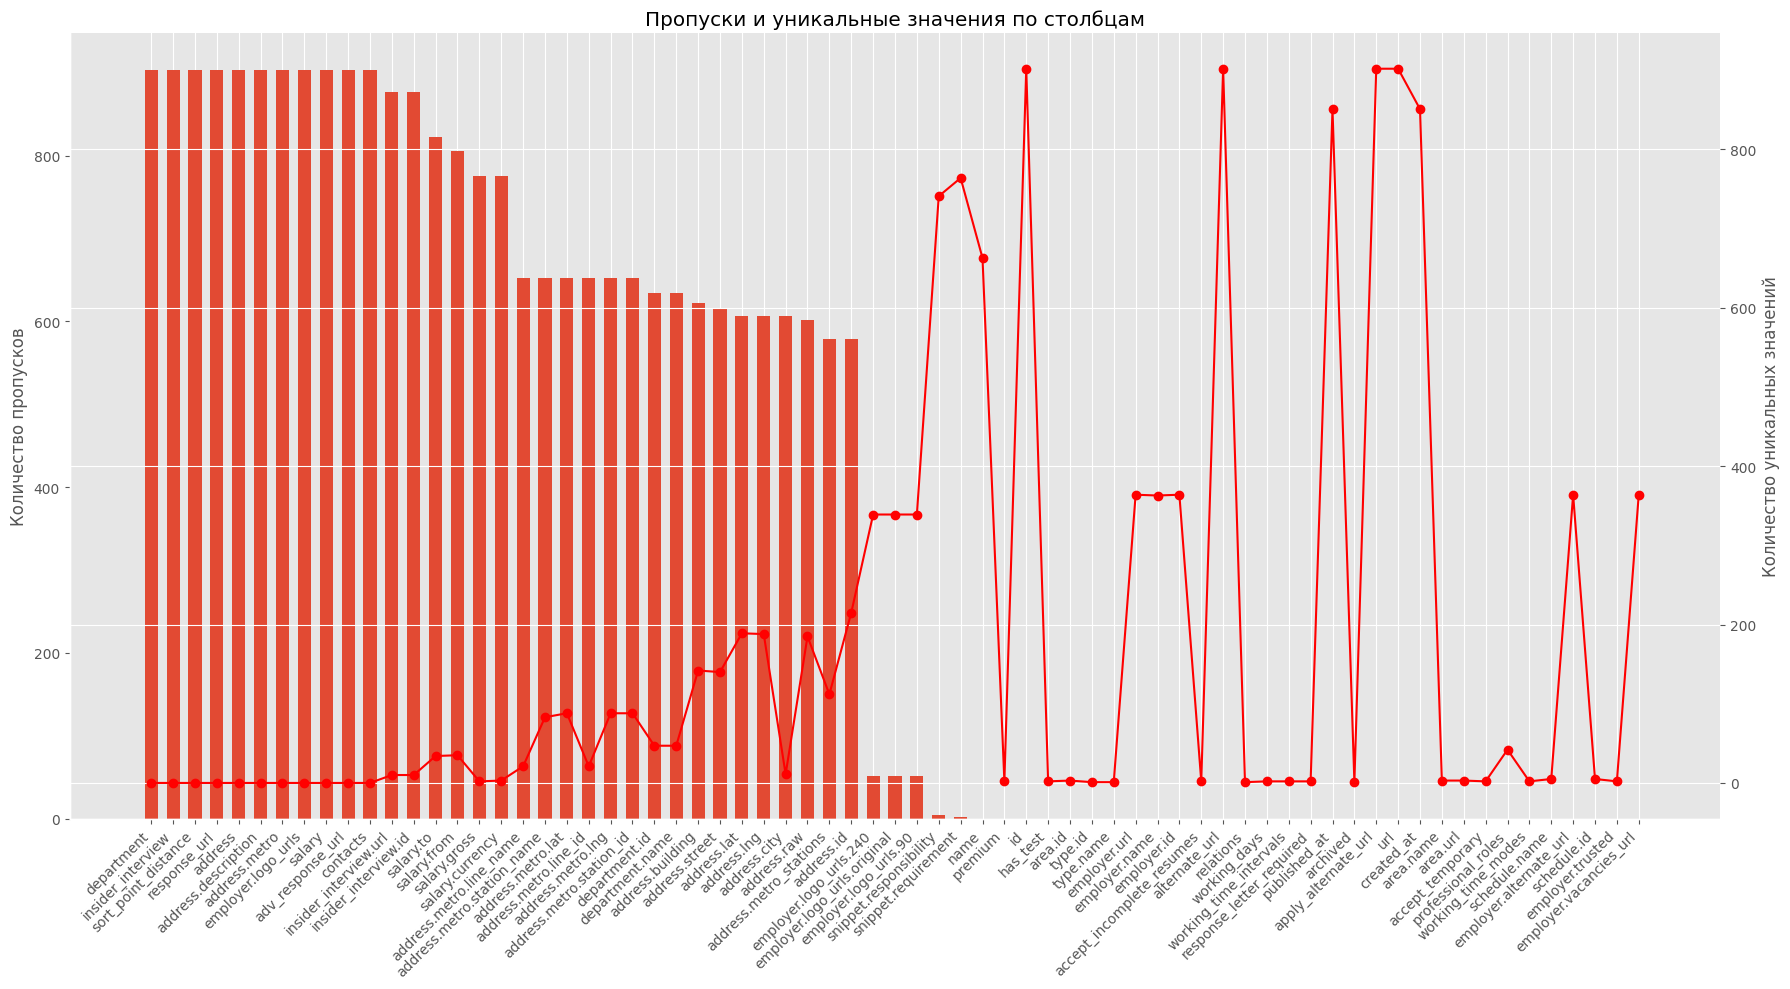

In [27]:
# Задание 2
stats = pd.DataFrame({
    "missing": df.isna().sum(),
    "unique": df.nunique()
})

stats = stats.sort_values(by="missing", ascending=False)

x = np.arange(len(stats))

fig, ax1 = plt.subplots(figsize=(18, 10))
ax1.set_facecolor("#E6E6E6")
bar_width = 0.6
ax1.bar(x, stats["missing"], width=bar_width)
ax2 = ax1.twinx()
ax2.plot(x, stats["unique"], marker='o', c='red')
ax1.set_xticks(x)
ax1.set_xticklabels(stats.index, rotation=45, ha='right')
ax1.set_ylabel("Количество пропусков")
ax2.set_ylabel("Количество уникальных значений")
ax1.set_title("Пропуски и уникальные значения по столбцам")
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax1.grid(axis='y')

plt.tight_layout()
plt.show()

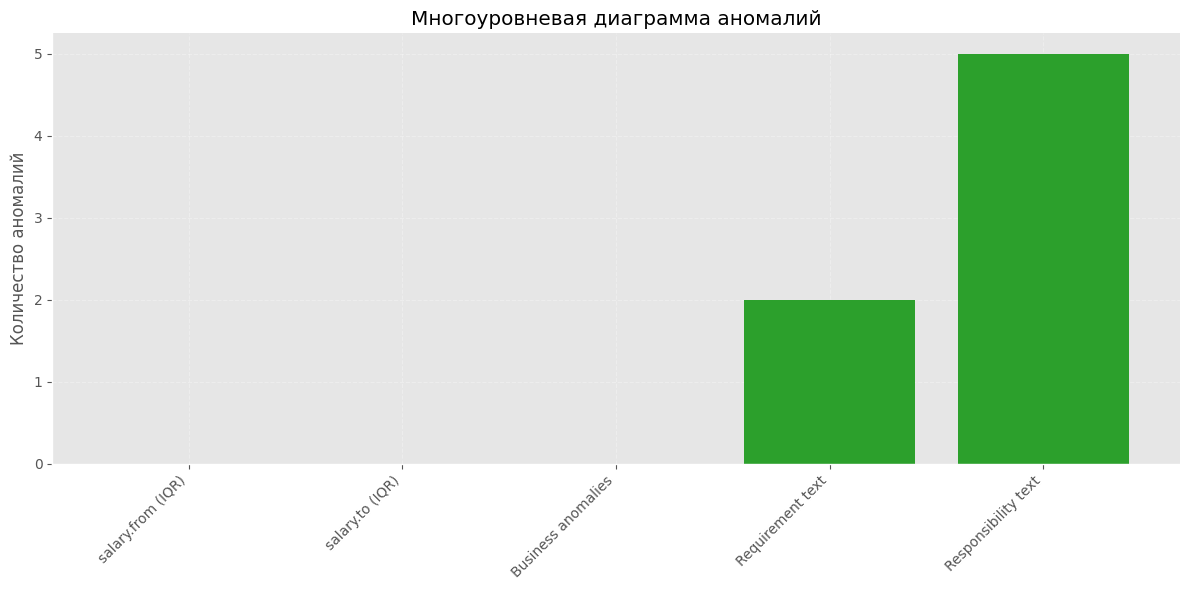

In [28]:
# Задание 3

salary_from = df["salary.from"]
salary_to = df["salary.to"]

def tukey_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

outlier_from = tukey_outliers(salary_from)
outlier_to = tukey_outliers(salary_to)


biz_anomaly = (
    (salary_from < 0) |
    (salary_to < 0) |
    (salary_from > salary_to)
)

req_len = df["snippet.requirement"].astype(str).str.len()
resp_len = df["snippet.responsibility"].astype(str).str.len()

text_anomaly_req = (req_len < 10) | (req_len > 1000)
text_anomaly_resp = (resp_len < 10) | (resp_len > 1000)

anomaly_stats = pd.DataFrame({
    "salary.from (IQR)": outlier_from.sum(),
    "salary.to (IQR)": outlier_to.sum(),
    "Business anomalies": biz_anomaly.sum(),
    "Requirement text": text_anomaly_req.sum(),
    "Responsibility text": text_anomaly_resp.sum()
}, index=["count"]).T

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_facecolor("#E6E6E6")
ax.grid(True, linestyle='--', alpha=0.3)

labels = anomaly_stats.index
values = anomaly_stats["count"].values

colors = [
    "tab:blue",  
    "tab:blue",   
    "tab:orange", 
    "tab:green",  
    "tab:green"  
]

bars = ax.bar(labels, values, color=colors)
ax.set_title("Многоуровневая диаграмма аномалий")
ax.set_ylabel("Количество аномалий")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

[0.1, 0, 0]


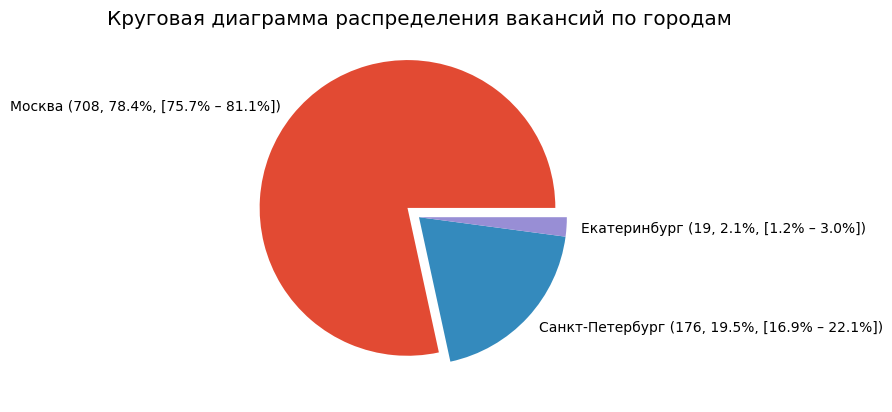

In [29]:
# Задание 4
counts = df['area.name'].value_counts()
total = counts.sum()
max_value = counts.max()

p = counts / total
se = (p * (1 - p) / total) ** 0.5
z = 1.96
lower = p - z * se
upper = p + z * se
lower = lower.clip(0, 1)
upper = upper.clip(0, 1)

labels = [
    f"{city} ({count}, {p[city]*100:.1f}%, "
    f"[{lower[city]*100:.1f}% – {upper[city]*100:.1f}%])"
    for city, count in counts.items()
]
plt.title('Круговая диаграмма распределения вакансий по городам')
explode = [0.1 if x == max_value else 0 for x in counts.values]
plt.pie(counts, labels=labels, explode=explode)
print(explode)
plt.show()

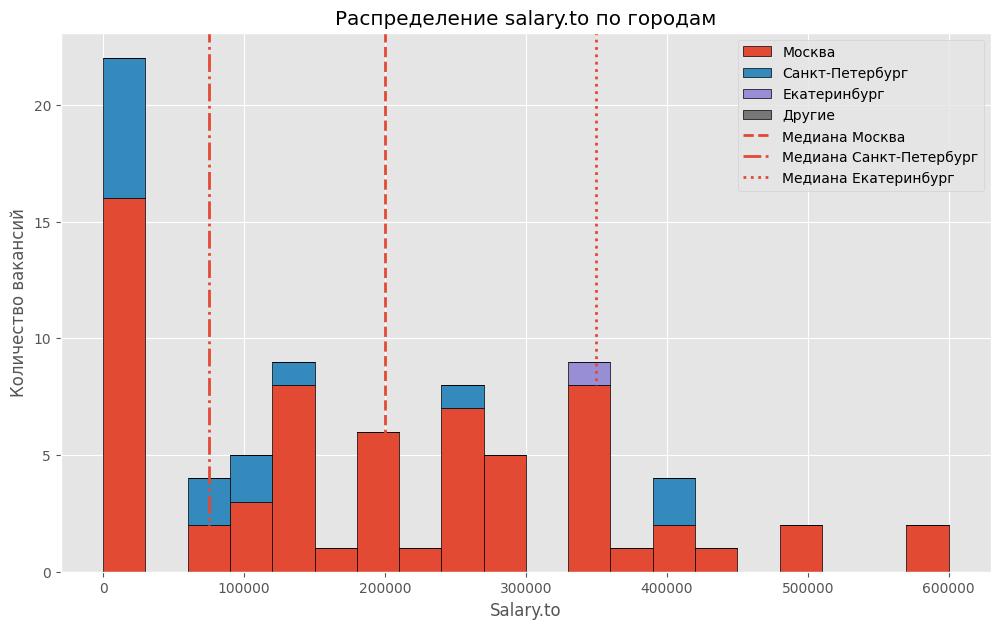

In [30]:
# Задание 5
data = df.dropna(subset=['salary.to', 'area.name']).copy()

top_cities = data['area.name'].value_counts().nlargest(5).index
data['city_grouped'] = data['area.name'].where(
    data['area.name'].isin(top_cities),
    'Другие'
)

labels = list(top_cities) + ['Другие']
grouped_data = [
    data.loc[data['city_grouped'] == city, 'salary.to']
    for city in labels
]

plt.figure(figsize=(12, 7))

plt.hist(
    grouped_data,
    bins=20,
    stacked=True,
    label=labels,
    edgecolor='black'
)

linestyles = ['--', '-.', ':', '-', (0, (3, 1, 1, 1))]

for city, style in zip(top_cities, linestyles):
    median_value = data.loc[data['area.name'] == city, 'salary.to'].median()
    
    plt.axvline(
        median_value,
        linestyle=style,
        linewidth=2,
        label=f'Медиана {city}'
    )

# 7. Оформление
plt.xlabel('Salary.to')
plt.ylabel('Количество вакансий')
plt.title('Распределение salary.to по городам')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\Normc\AppData\Local\Temp\ipykernel_26676\396189097.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot.applymap(lambda x: "" if pd.isna(x) else f"{int(round(x, -4) / 1000)}k")


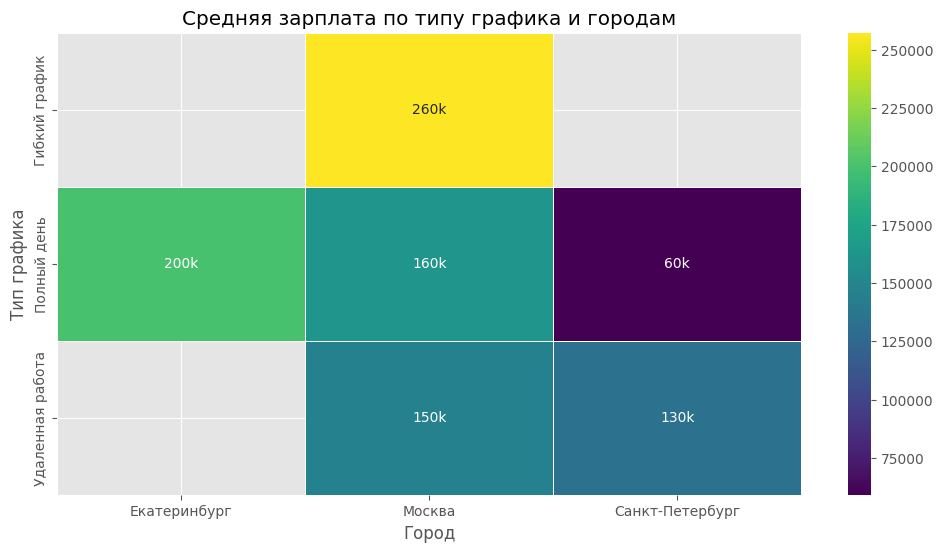

In [31]:
# Задание 6
df['salary_mid'] = df[['salary.from', 'salary.to']].mean(axis=1)
data = df.dropna(subset=['salary_mid', 'schedule.name', 'area.name']).copy()
top_cities = data['area.name'].value_counts().nlargest(7).index

data = data[data['area.name'].isin(top_cities)]

pivot = data.pivot_table(
    values='salary_mid',
    index='schedule.name',
    columns='area.name',
    aggfunc='mean'
)

annot = pivot.copy()

annot = pivot.applymap(lambda x: "" if pd.isna(x) else f"{int(round(x, -4) / 1000)}k")

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot,
    cmap='viridis',
    annot=annot,
    fmt="",
    linewidths=0.5
)

plt.title('Средняя зарплата по типу графика и городам')
plt.xlabel('Город')
plt.ylabel('Тип графика')

plt.show()

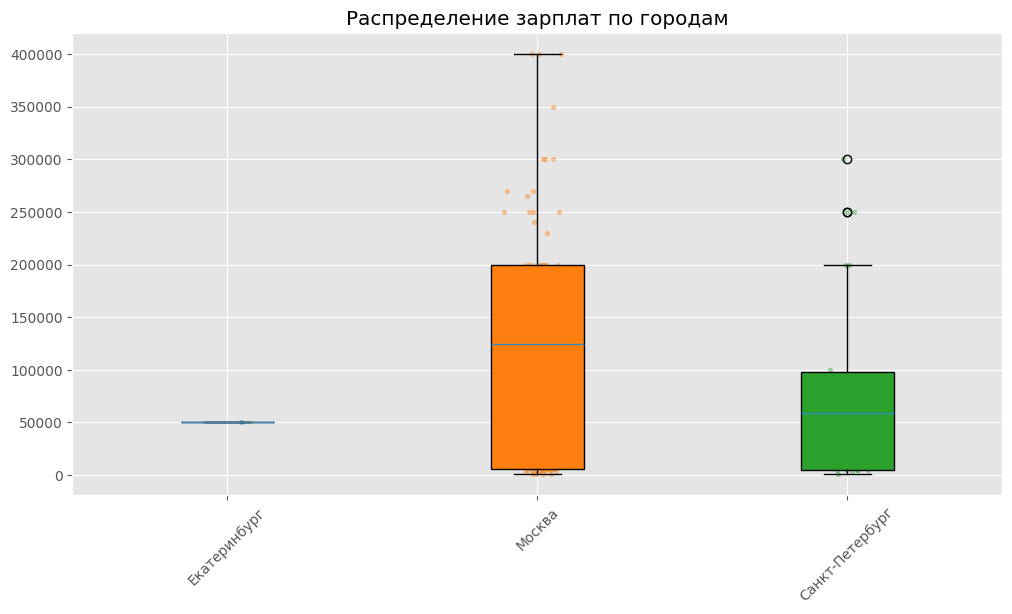

In [32]:
# Задание 7
cities = sorted(df['area.name'].dropna().unique())
data = [df[df['area.name'] == city]['salary.from'].dropna().values for city in cities]

colors = plt.cm.tab10.colors
city_color = {city: colors[i % 10] for i, city in enumerate(cities)}

plt.figure(figsize=(12, 6))

bp = plt.boxplot(data, patch_artist=True)

for patch, city in zip(bp['boxes'], cities):
    patch.set_facecolor(city_color[city])

for i, city in enumerate(cities):
    y = df[df['area.name'] == city]['salary.from'].dropna()
    x = np.random.normal(i + 1, 0.04, size=len(y)) 

    plt.scatter(x, y, alpha=0.4, color=city_color[city], s=10)

plt.xticks(range(1, len(cities) + 1), cities, rotation=45)
plt.title('Распределение зарплат по городам')
plt.show()

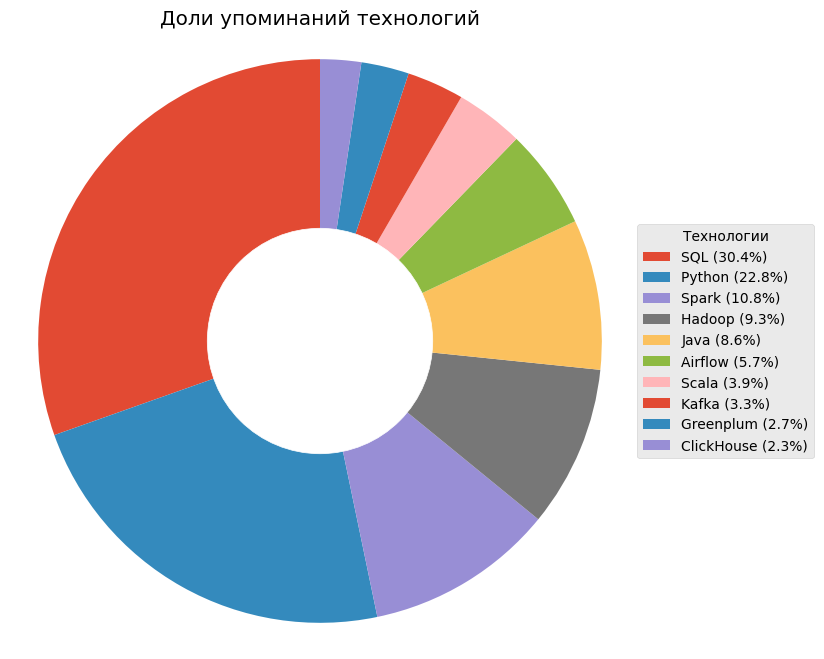

In [ ]:
# Задание 8
techs = ["Python", "SQL", "Spark", "Hadoop", "Airflow", "Kafka", 
         "Java", "Scala", "ClickHouse", "Greenplum"]

pattern = r'\b(' + '|'.join(techs) + r')\b'


extracted = df['snippet.requirement'].dropna().apply(
    lambda x: re.findall(pattern, x)
)

all_techs = [tech for sublist in extracted for tech in sublist]
counts = pd.Series(all_techs).value_counts()

percent = counts / counts.sum() * 100

labels = [f"{tech} ({p:.1f}%)" for tech, p in percent.items()]

plt.figure(figsize=(8, 8))
wedges, _ = plt.pie(
    counts,
    labels=None
)

centre_circle = plt.Circle((0, 0), 0.4, color='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.legend(wedges, labels, title="Технологии", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Доли упоминаний технологий")
plt.axis('equal')
plt.show()

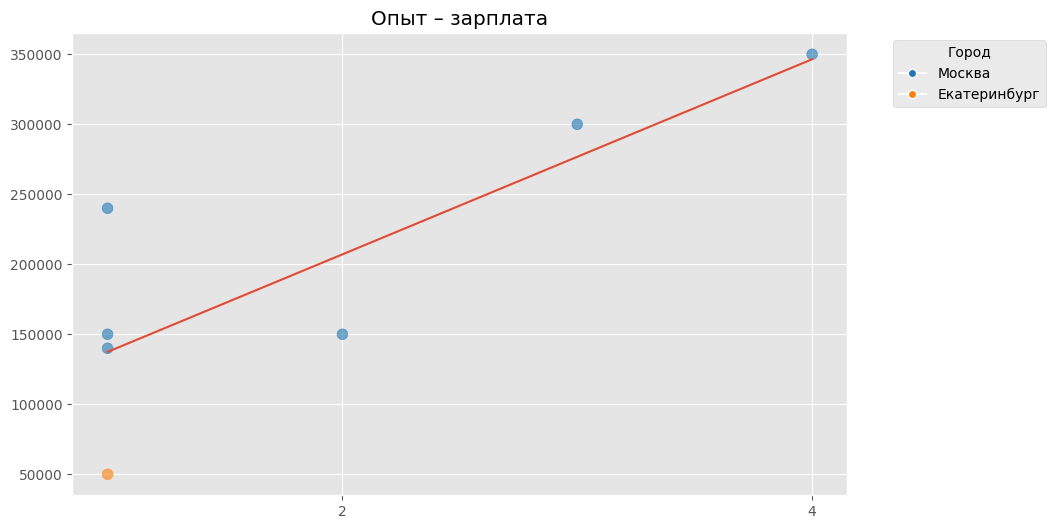

In [34]:
from matplotlib.ticker import MultipleLocator

df['experience'] = df['snippet.requirement'].str.extract(r'(\d+)\s*(?:год|лет)').astype(float)
data = df.dropna(subset=['experience', 'salary.from', 'area.name']).copy()

data['exp_bin'] = (data['experience'] // 2) * 2
data['salary_bin'] = (data['salary.from'] // 50000) * 50000

counts = (
    data.groupby(['exp_bin', 'salary_bin'])
    .size()
    .reset_index(name='count')
)

data = data.merge(counts, on=['exp_bin', 'salary_bin'], how='left')

palette = plt.get_cmap('tab10')
cities = data['area.name'].unique()
city_colors = {city: palette(i % 10) for i, city in enumerate(cities)}

data['color'] = data['area.name'].map(city_colors)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    data['experience'],
    data['salary.from'],
    c=data['color'],
    s=data['count'] * 60,
    alpha=0.6,
)

coef = np.polyfit(data['experience'], data['salary.from'], 1)
poly = np.poly1d(coef)

x_line = np.linspace(data['experience'].min(), data['experience'].max(), 100)
y_line = poly(x_line)

ax.plot(x_line, y_line)
ax.set_title('Опыт – зарплата')

ax.xaxis.set_major_locator(MultipleLocator(2))
ax.grid(True)

handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=city_colors[city],
               label=city, markersize=6)
    for city in cities
]

ax.legend(handles=handles, title='Город', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

C:\Users\Normc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


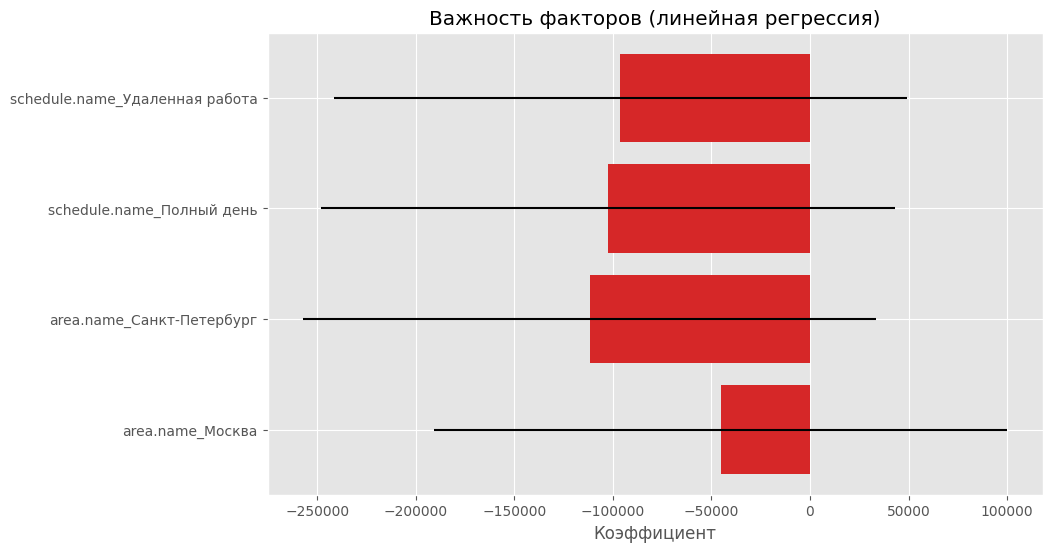

In [ ]:
# Задание 10
data = df.dropna(subset=['salary_mid', 'area.name', 'schedule.name']).copy()

top5 = data['area.name'].value_counts().head(5).index
data['area.name'] = data['area.name'].where(data['area.name'].isin(top5), 'Other')

X = pd.get_dummies(data[['area.name', 'schedule.name']], drop_first=True)

y = data['salary_mid']

model = LinearRegression()
model.fit(X, y)

coef = model.coef_

X_mat = X.values
n, p = X_mat.shape

y_pred = model.predict(X_mat)
residuals = y - y_pred

sigma2 = (residuals @ residuals) / (n - p)

XtX_inv = np.linalg.inv(X_mat.T @ X_mat)
se = np.sqrt(np.diag(sigma2 * XtX_inv))

error = 1.96 * se

colors = ['#1f77b4' if c > 0 else '#d62728' for c in coef]

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(coef))
ax.barh(y_pos, coef, xerr=error, color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(X.columns)
ax.set_xlabel('Коэффициент')
ax.set_title('Важность факторов (линейная регрессия)')
ax.grid(True)

plt.show()

C:\Users\Normc\AppData\Local\Temp\ipykernel_26676\3450347210.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['published_at'].dt.to_period('M')


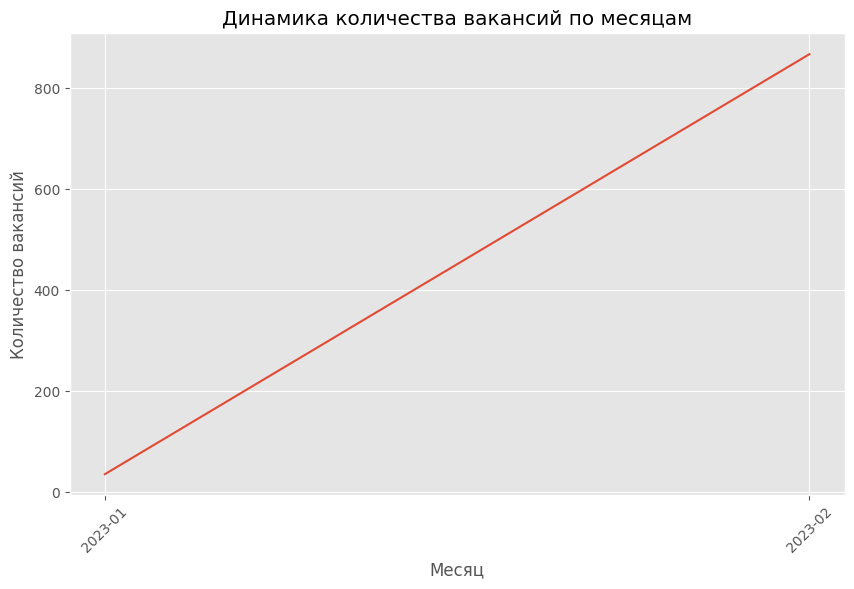

In [ ]:
# Задание 11
df['published_at'] = pd.to_datetime(df['published_at'])
df['month'] = df['published_at'].dt.to_period('M')

monthly_counts = df.groupby('month').size()

monthly_counts.index = monthly_counts.index.to_timestamp()

plt.figure(figsize=(10, 6))
plt.plot(monthly_counts.index, monthly_counts.values)
plt.title('Динамика количества вакансий по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество вакансий')
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

plt.show()

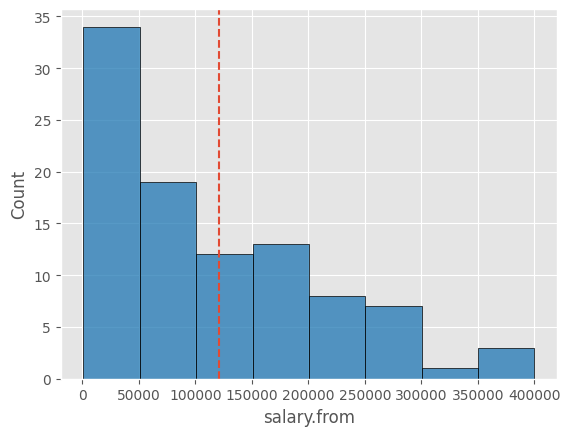

In [51]:
# Задание 12
sns.histplot(df.loc[df['salary.from'].notna(), 'salary.from'], bins='auto', color='#1f77b4', edgecolor='black')
plt.axvline(df.loc[df['salary.from'].notna(), 'salary.from'].mean(), linestyle='--')

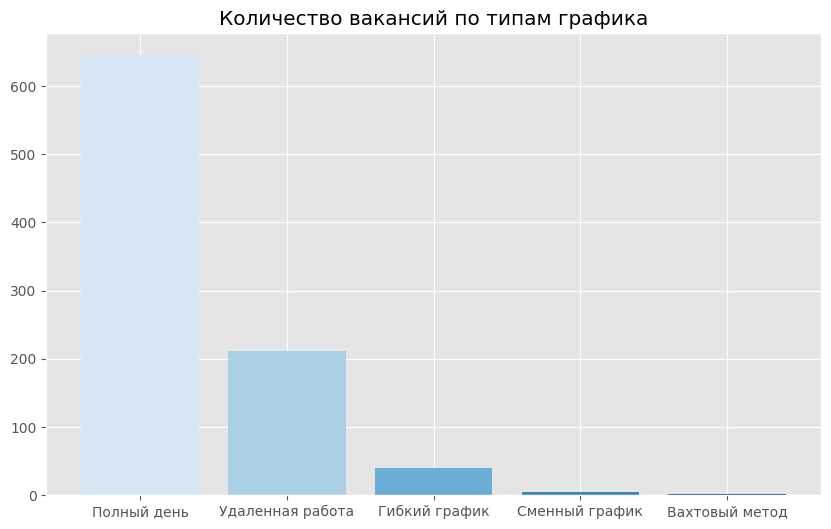

In [ ]:
# Задание 13
counts = df['schedule.name'].value_counts()
colors = sns.color_palette("Blues", n_colors=len(counts))

plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values, color=colors)
plt.title('Количество вакансий по типам графика')
plt.show()

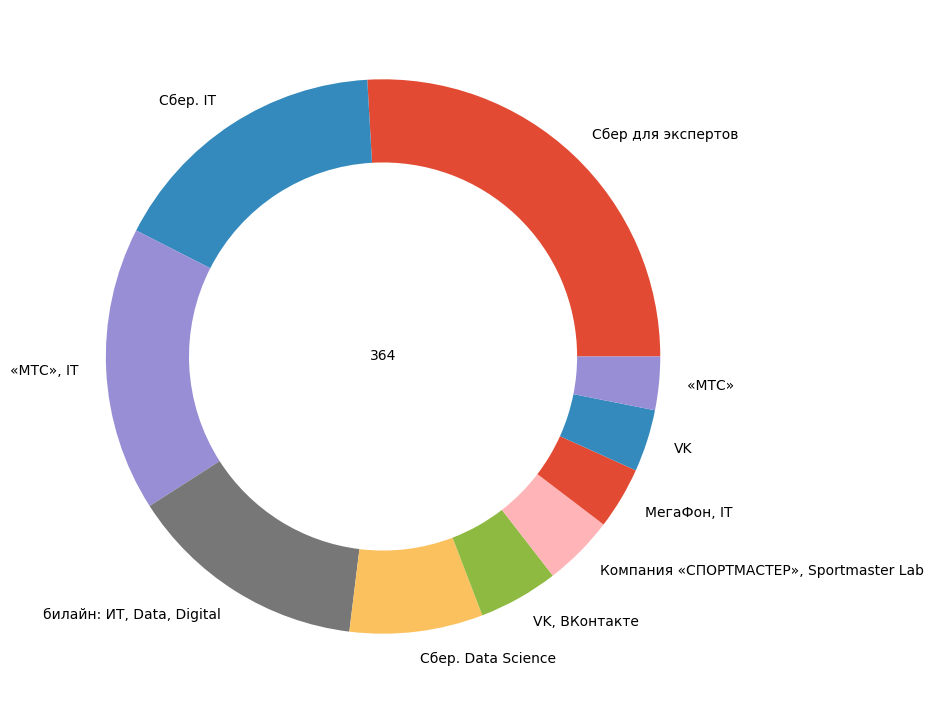

In [89]:
# Задание 14
fig, ax = plt.subplots(figsize=(15, 9))
n_employers = df['employer.id'].nunique()
ax.pie(df['department.name'].value_counts()[:10], wedgeprops = {'width': 0.3}, labels=df['department.name'].value_counts()[:10].index,)
ax.text(0, 0, str(n_employers), ha='center', va='center')
plt.show()

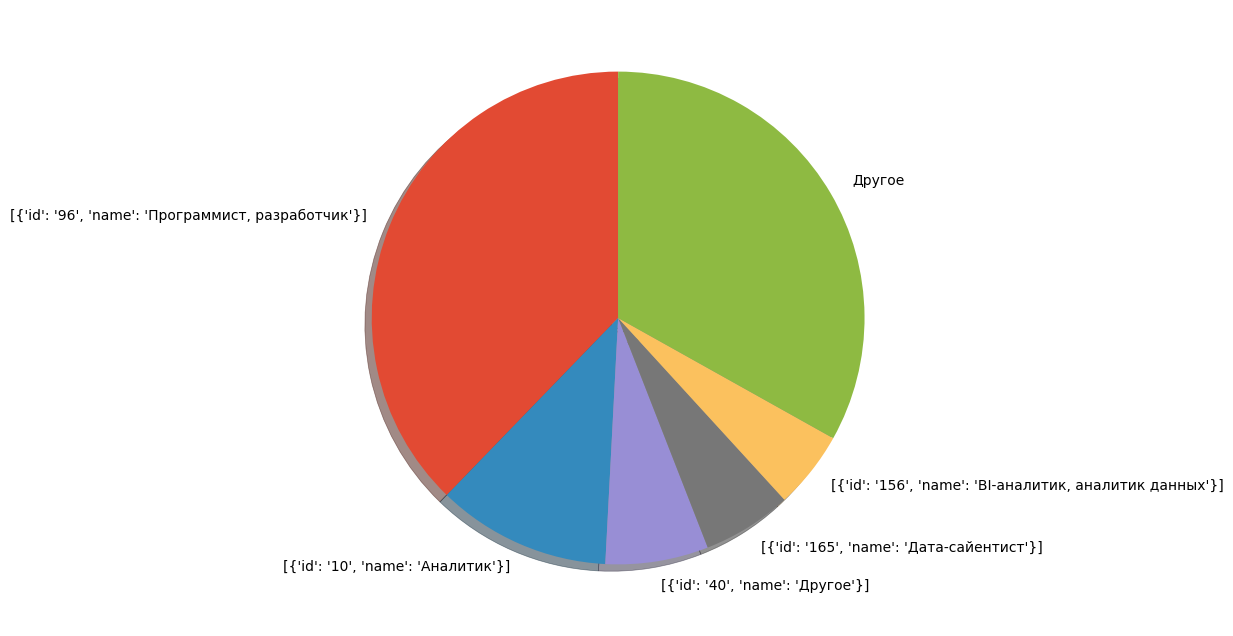

In [ ]:
# Задание 15
counts = df['professional_roles'].value_counts()
top5 = counts[:5]
others = counts[5:].sum()

data = top5
data['Другое'] = others

plt.figure(figsize=(15, 8))
plt.pie(data, labels=data.index, shadow=True, startangle=90)

plt.show()

In [ ]:
df['has_test'].value_counts().inted

Index([False, True], dtype='bool', name='has_test')

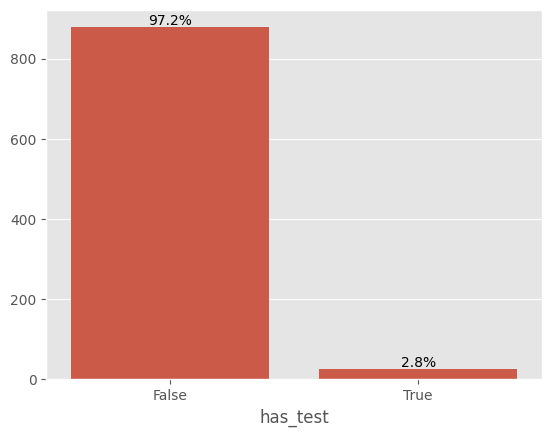

In [140]:
# Задание 16
counts = df['has_test'].value_counts()

sns.barplot(x=counts.index, y=counts.values)
total = counts.sum()
for i, value in enumerate(counts.values):
    plt.text(i, value, f'{value/total:.1%}', ha='center', va='bottom')

plt.show()

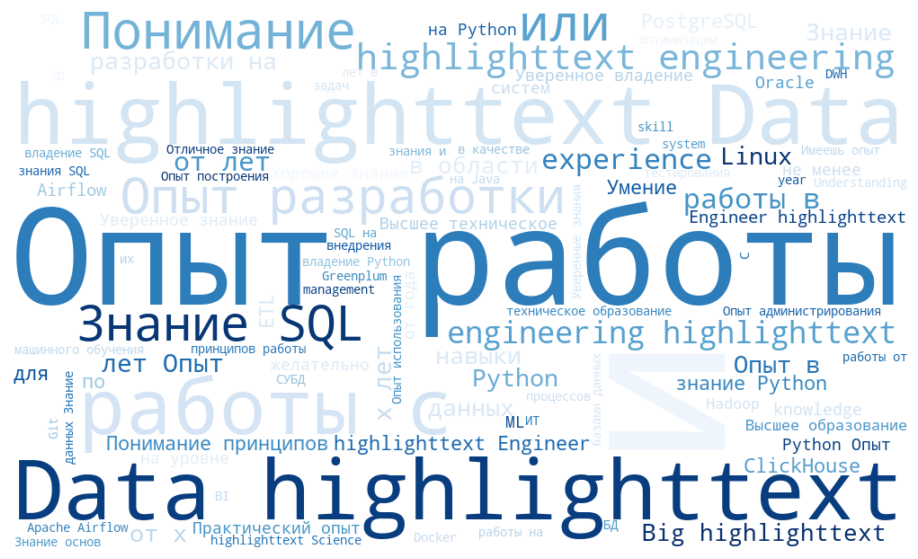

In [150]:
# Задание 17
texts = df['snippet.requirement'].dropna()
text = ' '.join(texts)

wc = WordCloud(
    width=1000,
    height=600,
    max_words=100,        # ограничение слов
    colormap='Blues',     # цветовая схема
    background_color='white'
).generate(text)
plt.figure(figsize=(12, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

# Задание 18

Гипотеза 1:
Формулировка:
Если в вакансии явно указаны технологии (Python, Spark, Kafka), то количество откликов выше.

Гипотеза 2:
Формулировка:
Вакансии с удалённым форматом работы имеют больше откликов при сопоставимой зарплате.

Гипотеза 3:
Формулировка:
Вакансии с более высокой зарплатой содержат более сложные требования.

Гипотеза 4:
Формулировка:
В крупных городах (Москва, Санкт-Петербург) уровень зарплат выше, чем в регионах.

Гипотеза 5:
Формулировка:
Наличие тестового задания снижает количество откликов.

,Hypothesis,Impact,Confidence,Ease,ICE
4,Тест → отклики,8,8,9,576
3,География → зарплата,7,9,9,567
0,Технологии → отклики,9,8,7,504
1,Remote → отклики,8,7,8,448
2,Зарплата → сложность,9,6,6,324


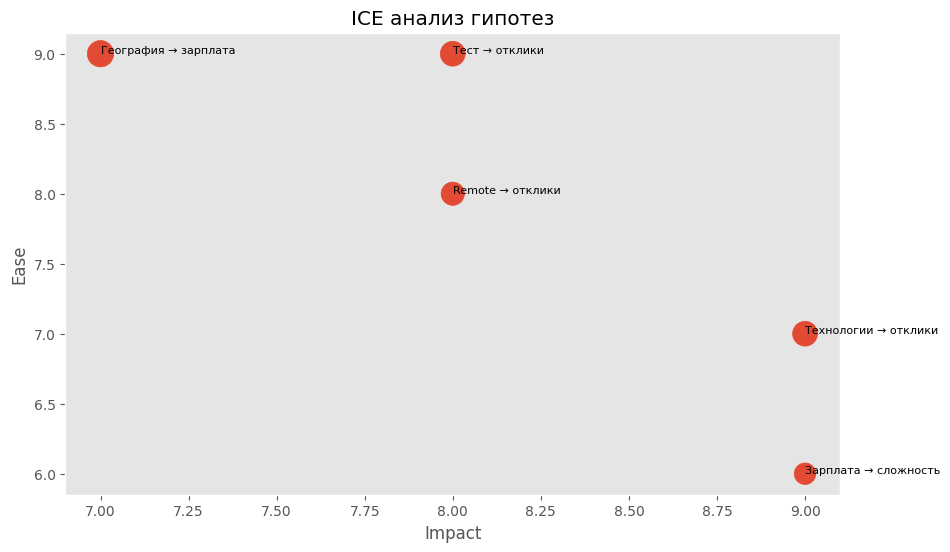

In [164]:
# Задание 19
data = [
    ["Технологии → отклики", 9, 8, 7],
    ["Remote → отклики", 8, 7, 8],
    ["Зарплата → сложность", 9, 6, 6],
    ["География → зарплата", 7, 9, 9],
    ["Тест → отклики", 8, 8, 9],
]

df_ice = pd.DataFrame(data, columns=["Hypothesis", "Impact", "Confidence", "Ease"])
df_ice["ICE"] = df_ice["Impact"] * df_ice["Confidence"] * df_ice["Ease"]

display(df_ice.sort_values("ICE", ascending=False))

plt.figure(figsize=(10, 6))

plt.scatter(
    df_ice["Impact"],
    df_ice["Ease"],
    s=df_ice["Confidence"] * 40
)

for i, row in df_ice.iterrows():
    plt.text(row["Impact"], row["Ease"], row["Hypothesis"], fontsize=8)

plt.xlabel("Impact")
plt.ylabel("Ease")
plt.title("ICE анализ гипотез")

plt.grid()
plt.show()

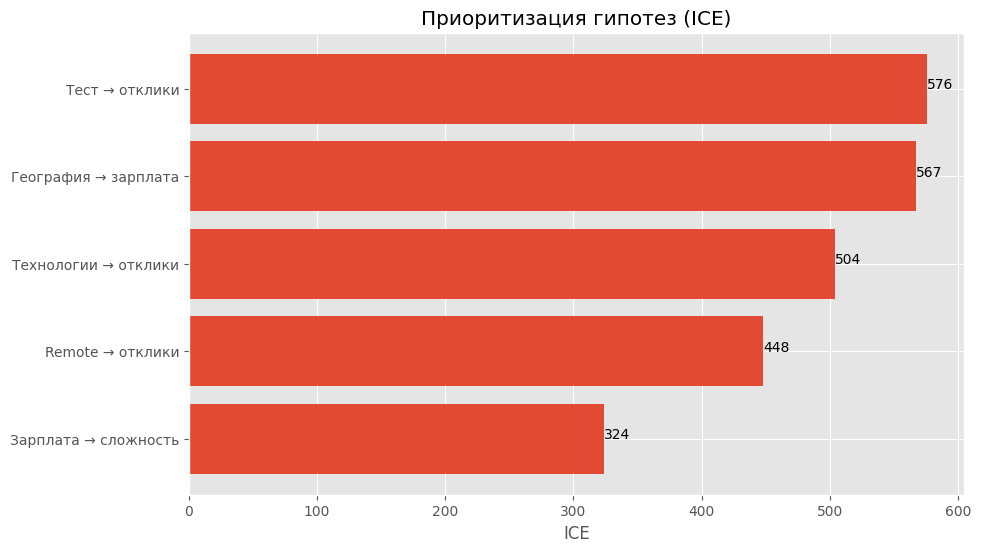

In [167]:
# Задание 20
df_sorted = df_ice.sort_values("ICE")

plt.figure(figsize=(10, 6))

plt.barh(df_sorted["Hypothesis"], df_sorted["ICE"])

for i, value in enumerate(df_sorted["ICE"]):
    plt.text(value, i, str(int(value)))

plt.xlabel("ICE")
plt.title("Приоритизация гипотез (ICE)")
plt.show()

# Задание 20
Приоритетные гипотезы:

1) **Тестовое задание → отклики**
- максимальный баланс влияния и простоты проверки
- быстро проверяется → высокая практическая ценность
2) **География → зарплата**
- высокая уверенность (много данных)
- легко проверяется
3) **Технологии → отклики**
- высокий бизнес-эффект
- важна для оптимизации вакансий